<a href="https://colab.research.google.com/github/grownsandip/ML_Algo/blob/main/Comedy_show_decision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**First we connect the google drive  as it contains our dataset**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


NEXT WE import the dataset from the drive to our colab environment

In [2]:
import pandas as pd
path ="/content/drive/MyDrive/comedy_dataset/shows.csv"
data = pd.read_csv(path) #variable data for storing loaded dataset
data.head()

,Age,Experience,Rank,Nationality,Go
0,36,10,9,UK,NO
1,42,12,4,USA,NO
2,23,4,6,N,NO
3,52,4,4,USA,NO
4,43,21,8,USA,YES


we need to convert the nationality such into binary values

In [3]:
d={"UK":0,"USA":1,"N":2} #representing numerical value as Nationality
data["Nationality"]=data["Nationality"].map(d) # mapping all natinalities to key value pair
print(data)

    Age  Experience  Rank  Nationality   Go
0    36          10     9            0   NO
1    42          12     4            1   NO
2    23           4     6            2   NO
3    52           4     4            1   NO
4    43          21     8            1  YES
5    44          14     5            0   NO
6    66           3     7            2  YES
7    35          14     9            0  YES
8    52          13     7            2  YES
9    35           5     9            2  YES
10   24           3     5            1   NO
11   18           3     7            0  YES
12   45           9     9            0  YES


In [4]:
d={"YES":1,"NO":0}
data["Go"]=data["Go"].map(d)
print(data)

    Age  Experience  Rank  Nationality  Go
0    36          10     9            0   0
1    42          12     4            1   0
2    23           4     6            2   0
3    52           4     4            1   0
4    43          21     8            1   1
5    44          14     5            0   0
6    66           3     7            2   1
7    35          14     9            0   1
8    52          13     7            2   1
9    35           5     9            2   1
10   24           3     5            1   0
11   18           3     7            0   1
12   45           9     9            0   1


next we seperate the features and target columns

In [5]:
features = ['Age', 'Experience', 'Rank', 'Nationality']
X = data[features]
print(X)

    Age  Experience  Rank  Nationality
0    36          10     9            0
1    42          12     4            1
2    23           4     6            2
3    52           4     4            1
4    43          21     8            1
5    44          14     5            0
6    66           3     7            2
7    35          14     9            0
8    52          13     7            2
9    35           5     9            2
10   24           3     5            1
11   18           3     7            0
12   45           9     9            0


In [6]:
# y is the target column:
Y = data['Go']
print(Y)

0     0
1     0
2     0
3     0
4     1
5     0
6     1
7     1
8     1
9     1
10    0
11    1
12    1
Name: Go, dtype: int64


In [8]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
dtree=tree.DecisionTreeClassifier()
dtree=dtree.fit(X,Y)

Now we see the tree diagram

[Text(0.3333333333333333, 0.875, 'x[2] <= 6.5\ngini = 0.497\nsamples = 13\nvalue = [6, 7]'),
 Text(0.16666666666666666, 0.625, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.25, 0.75, 'True  '),
 Text(0.5, 0.625, 'x[1] <= 9.5\ngini = 0.219\nsamples = 8\nvalue = [1, 7]'),
 Text(0.41666666666666663, 0.75, '  False'),
 Text(0.3333333333333333, 0.375, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.6666666666666666, 0.375, 'x[1] <= 11.5\ngini = 0.375\nsamples = 4\nvalue = [1, 3]'),
 Text(0.5, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8333333333333334, 0.125, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]')]

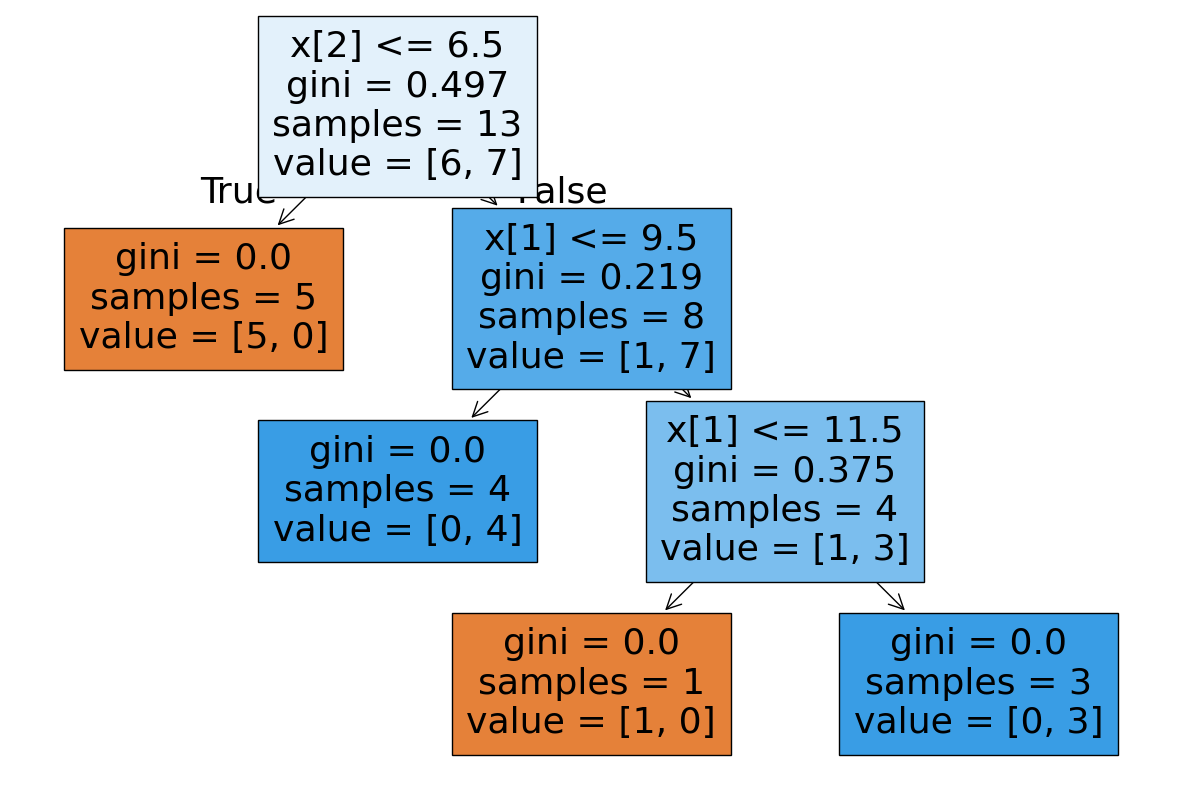

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,10))
tree.plot_tree(dtree,filled=True)

 Question: Should I go see a show starring a 40 years old American comedian with 10 years of experience,and a comedy ranking of 7?

In [19]:

sample_input = pd.DataFrame([[40, 10, 7, 1]], columns=['Age', 'Experience', 'Rank', 'Nationality'])

# Making prediction
print(dtree.predict(sample_input))

[0]
